# FASE 3 — Diagnóstico Operacional e Modelo de ROI
**Challenge 002 — Redesign de Suporte (G4 Educação)** · Autor: Thales Barbosa · 2026-07-16

Responde às 3 perguntas do Diretor de Operações. Conclusões executivas e tabela de rastreabilidade
requisito→seção: [`docs/diagnostic_report.md`](../docs/diagnostic_report.md). Modelo econômico (fonte única):
[`src/roi_model.py`](../src/roi_model.py), coberto por [`tests/test_roi_model.py`](../tests/test_roi_model.py).

**Guardrails herdados:** análises principais usam apenas features `measured` (D-005/D-008); colunas sintéticas
aparecem SÓ nas seções demonstrativas rotuladas, com marca d'água dentro das figuras (D-011). Espec revisada
por painel de 3 lentes antes da implementação (D-010, `process-log/decisions.md`).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_prep import AGENT_COST_BRL_PER_HOUR, TICKETS_PER_YEAR
from src.roi_model import (
    roi_scenario, roi_business_scenario, break_even_deflection,
    workload_by_segment, sensitivity_tornado,
    DEFLECTION_BY_TYPE, ASSIST_AHT_REDUCTION, RAMP_UP_YEAR1,
    SOLUTION_IMPL_COST_BRL, SOLUTION_RUN_COST_PER_TICKET_BRL,
    FTE_PRODUCTIVE_HOURS_YEAR, TICKETS_PER_YEAR_RANGE,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
BLUE, ORANGE, RED = sns.color_palette("deep")[0], sns.color_palette("deep")[1], "crimson"
ASSETS = Path("../docs/assets")

def watermark(ax, txt="DADOS SINTÉTICOS — DEMONSTRATIVO"):
    ax.text(0.5, 0.5, txt, transform=ax.transAxes, alpha=0.22, fontsize=22,
            ha="center", va="center", rotation=18, color=RED, zorder=10, fontweight="bold")

d1 = pd.read_parquet("../data/processed/tickets_features.parquet")
closed = d1[d1["is_closed"]].copy()
SAT = "Customer Satisfaction Rating"
SEGS = ["Ticket Channel", "Ticket Type", "Ticket Priority"]
print(f"Base: {len(d1):,} tickets ({len(closed):,} Closed) | anualização p/ {TICKETS_PER_YEAR:,}/ano")

Base: 8,469 tickets (2,769 Closed) | anualização p/ 30,000/ano


---
# PERGUNTA 1 — Onde o fluxo trava?

**Disclosure simétrico:** os percentuais abaixo são o retrato dos dados *como entregues* — a auditoria (FASE 1)
mostrou distribuições uniformes típicas de gerador sintético, e a mesma ressalva vale para volumes, backlog e
satisfação. O que transfere para a operação real é o **método** e o **funil**.

## 1.1 O funil de status: o gargalo é sistêmico, não segmentado

Leitura de **snapshot** (foto do momento da extração), não de fluxo/aging — o dataset não tem timestamps
confiáveis para medir idade de fila (D-005).

                                n     %
Open (sem 1ª resposta)       2819  33.3
Pending (esperando cliente)  2881  34.0
Closed (resolvido)           2769  32.7

HEADLINE: 1 em cada 3 tickets (33.3%) nunca recebeu a primeira resposta
Dois problemas distintos, duas alavancas distintas:
  Open 33,3%    -> capacidade/triagem do TIME  -> auto-resposta + roteamento automático
  Pending 34,0% -> espera do CLIENTE           -> follow-up automatizado + auto-close com aviso


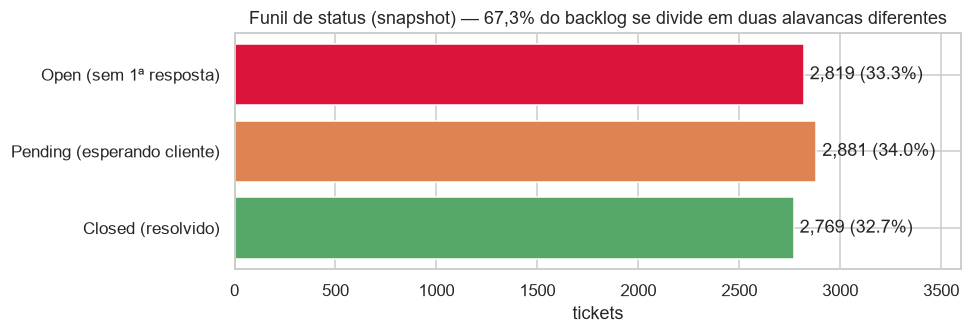

In [2]:
funil = pd.DataFrame({
    "n": [d1["is_open"].sum(), d1["is_pending"].sum(), d1["is_closed"].sum()],
}, index=["Open (sem 1ª resposta)", "Pending (esperando cliente)", "Closed (resolvido)"])
funil["%"] = (funil["n"] / len(d1) * 100).round(1)
print(funil.to_string())
print(f"\nHEADLINE: 1 em cada 3 tickets ({d1['is_open'].mean() * 100:.1f}%) nunca recebeu a primeira resposta")
print("Dois problemas distintos, duas alavancas distintas:")
print("  Open 33,3%    -> capacidade/triagem do TIME  -> auto-resposta + roteamento automático")
print("  Pending 34,0% -> espera do CLIENTE           -> follow-up automatizado + auto-close com aviso")

fig, ax = plt.subplots(figsize=(9, 3.2))
colors = [RED, ORANGE, sns.color_palette("deep")[2]]
bars = ax.barh(funil.index[::-1], funil["n"][::-1], color=colors[::-1])
for b, (n, p) in zip(bars, zip(funil["n"][::-1], funil["%"][::-1])):
    ax.text(b.get_width() + 30, b.get_y() + b.get_height() / 2, f"{n:,} ({p}%)", va="center")
ax.set_title("Funil de status (snapshot) — 67,3% do backlog se divide em duas alavancas diferentes")
ax.set_xlabel("tickets"); ax.set_xlim(0, 3600)
fig.tight_layout(); fig.savefig(ASSETS / "p3_funnel_status.png", bbox_inches="tight"); plt.show()

## 1.2 O backlog é uniforme entre segmentos (e esse nulo é informativo)

Se um canal/tipo/prioridade concentrasse o travamento, a automação deveria ser cirúrgica. Não é o caso:

       segmento   chi2      p  Cramér V  MDE (w, 80% poder)  p (BH-FDR)
 Ticket Channel 3.2952 0.7710    0.0139              0.0401      0.7710
    Ticket Type 9.0348 0.3394    0.0231              0.0421      0.5091
Ticket Priority 8.1550 0.2270    0.0219              0.0401      0.5091

Leitura: nenhum teste rejeita independência (todos p>0,10, V<0,02). Com n=8,469,
detectaríamos associações a partir de w~0,04 — o nulo é ALTAMENTE informativo:
não existe canal/tipo/prioridade 'vilão'. O travamento é do SISTEMA (67,3% em todo lugar).


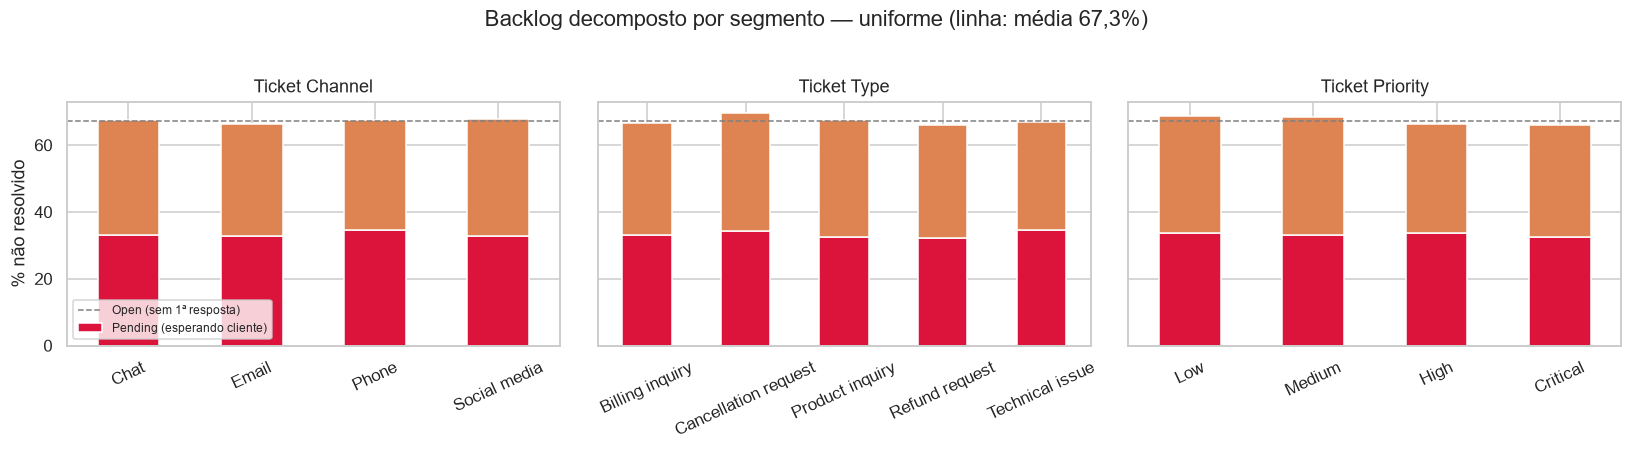

In [3]:
from statsmodels.stats.power import GofChisquarePower

rows = []
for col in SEGS:
    ct = pd.crosstab(d1[col], d1["Ticket Status"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramer_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    w_mde = GofChisquarePower().solve_power(effect_size=None, nobs=n, alpha=0.05,
                                            power=0.80, n_bins=dof + 1)
    rows.append({"segmento": col, "chi2": chi2, "p": p, "Cramér V": cramer_v, "MDE (w, 80% poder)": w_mde})
tab = pd.DataFrame(rows)
pvals_family = tab["p"].values
tab["p (BH-FDR)"] = stats.false_discovery_control(pvals_family)
print(tab.round(4).to_string(index=False))
print(f"\nLeitura: nenhum teste rejeita independência (todos p>0,10, V<0,02). Com n={len(d1):,},")
print("detectaríamos associações a partir de w~0,04 — o nulo é ALTAMENTE informativo:")
print("não existe canal/tipo/prioridade 'vilão'. O travamento é do SISTEMA (67,3% em todo lugar).")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, SEGS):
    g = d1.groupby(col, observed=True)[["is_open", "is_pending"]].mean() * 100
    g.plot(kind="bar", stacked=True, ax=ax, color=[RED, ORANGE], legend=(ax is axes[0]))
    ax.set_title(col); ax.set_ylabel("% não resolvido"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.axhline(67.3, ls="--", color="gray", lw=1)
if axes[0].get_legend():
    axes[0].legend(["Open (sem 1ª resposta)", "Pending (esperando cliente)"], fontsize=8)
fig.suptitle("Backlog decomposto por segmento — uniforme (linha: média 67,3%)", y=1.02)
fig.tight_layout(); fig.savefig(ASSETS / "p3_backlog_by_segment.png", bbox_inches="tight"); plt.show()

## 1.3 Satisfação por segmento (Closed, n=2.769): uniformemente ruim

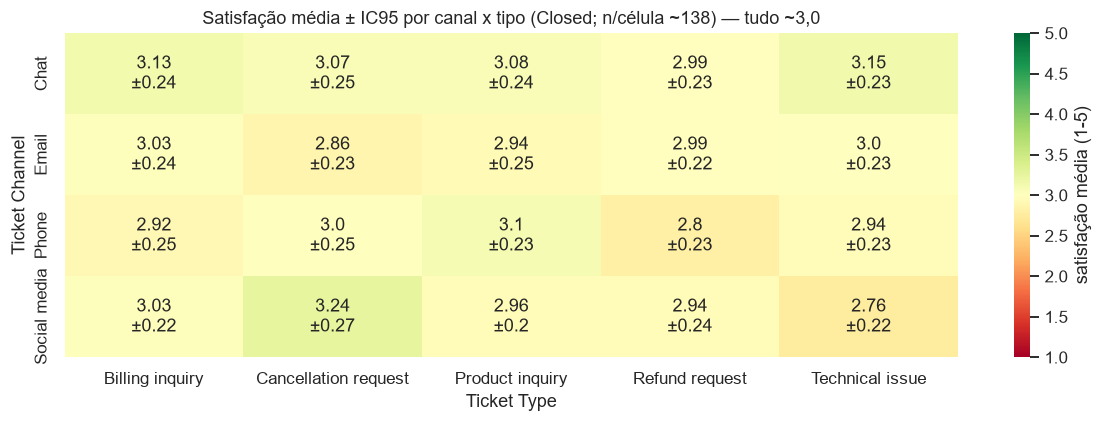

Média global: 2.99/5 | detratores (rating<=2): 39.8%
Range das médias por célula: 2.76 a 3.24
Os ICs (~±0,24 por célula) englobam a média global em todas as células -> flutuação amostral,
não padrão. Não há segmento a 'consertar' — a insatisfação é generalizada (39,8% detratores).


In [4]:
piv_mean = closed.pivot_table(values=SAT, index="Ticket Channel", columns="Ticket Type",
                              aggfunc="mean", observed=True)
piv_n = closed.pivot_table(values=SAT, index="Ticket Channel", columns="Ticket Type",
                           aggfunc="count", observed=True)
piv_se = closed.pivot_table(values=SAT, index="Ticket Channel", columns="Ticket Type",
                            aggfunc="sem", observed=True)
annot = piv_mean.round(2).astype(str) + "\n±" + (1.96 * piv_se).round(2).astype(str)
plt.figure(figsize=(11, 4))
sns.heatmap(piv_mean, annot=annot, fmt="", cmap="RdYlGn", vmin=1, vmax=5,
            cbar_kws={"label": "satisfação média (1-5)"})
plt.title(f"Satisfação média ± IC95 por canal x tipo (Closed; n/célula ~{int(piv_n.values.mean())}) — tudo ~3,0")
plt.tight_layout(); plt.savefig(ASSETS / "p3_satisfaction_heatmap.png", bbox_inches="tight"); plt.show()

det = closed["is_dissatisfied"].astype(bool)
print(f"Média global: {closed[SAT].mean():.2f}/5 | detratores (rating<=2): {det.mean() * 100:.1f}%")
print(f"Range das médias por célula: {piv_mean.values.min():.2f} a {piv_mean.values.max():.2f}")
print("Os ICs (~±0,24 por célula) englobam a média global em todas as células -> flutuação amostral,")
print("não padrão. Não há segmento a 'consertar' — a insatisfação é generalizada (39,8% detratores).")

## 1.4 Reincidência (único sinal relacional do dataset)

In [5]:
rep = d1.groupby("is_repeat_customer", observed=True).agg(
    n=("Ticket ID", "count"), backlog=("is_unresolved", "mean"))
rep["backlog"] = (rep["backlog"] * 100).round(1)
sat_rep = closed.groupby("is_repeat_customer", observed=True)[SAT].agg(["mean", "count"]).round(3)
print("Backlog por reincidência:"); print(rep.to_string())
print("\nSatisfação por reincidência (Closed):"); print(sat_rep.to_string())
ct = pd.crosstab(d1["is_repeat_customer"], d1["is_unresolved"])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"\nqui-quadrado backlog x reincidência: p={p:.3f} -> sem associação detectável.")
print("Caveat (FASE 2): e-mails repetidos podem ser colisão do gerador sintético (288 tickets, 3,4%).")

Backlog por reincidência:
                       n  backlog
is_repeat_customer               
False               8181     67.4
True                 288     63.2

Satisfação por reincidência (Closed):
                     mean  count
is_repeat_customer              
False               2.993   2663
True                2.943    106

qui-quadrado backlog x reincidência: p=0.147 -> sem associação detectável.
Caveat (FASE 2): e-mails repetidos podem ser colisão do gerador sintético (288 tickets, 3,4%).


## 1.5 Onde estão as horas: pools de carga (premissa-based)

Com tempos reais indisponíveis (D-005), a carga é estimada por `est_handle_minutes` (premissas declaradas,
FASE 2 §3). **Disclosure:** volumes são ~uniformes, então o ranking abaixo é majoritariamente dirigido pelas
premissas de esforço — ele responde "onde a automação libera mais horas *sob estas premissas*", e o tornado
da P3 mostra o quanto a resposta muda quando as premissas variam.

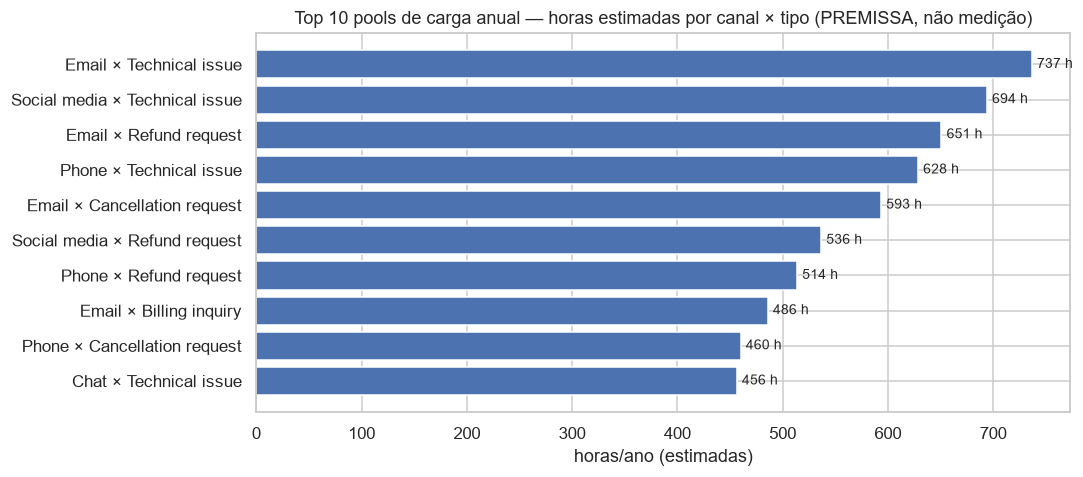

Combinação tripla canal × tipo × prioridade — top 10 por horas/ano:
Ticket Channel          Ticket Type Ticket Priority  tickets_year  hours_year
         Email      Technical issue        Critical         361.0       228.0
         Email      Technical issue            High         400.0       216.0
         Email Cancellation request        Critical         453.0       209.0
         Email       Refund request        Critical         407.0       205.0
  Social media      Technical issue        Critical         383.0       201.0
  Social media      Technical issue            High         443.0       199.0
         Phone      Technical issue        Critical         354.0       186.0
         Phone      Technical issue            High         407.0       183.0
  Social media       Refund request        Critical         422.0       177.0
         Email      Billing inquiry        Critical         397.0       167.0

Total: 9,207 h/ano | Technical issue lidera todos os canais
(multiplicado

In [6]:
w2 = workload_by_segment(d1)  # canal x tipo
top10 = w2.head(10)
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = top10["Ticket Channel"].astype(str) + " × " + top10["Ticket Type"].astype(str)
ax.barh(labels[::-1], top10["hours_year"][::-1], color=BLUE)
for i, v in enumerate(top10["hours_year"][::-1]):
    ax.text(v + 5, i, f"{v:,.0f} h", va="center", fontsize=9)
ax.set_title("Top 10 pools de carga anual — horas estimadas por canal × tipo (PREMISSA, não medição)")
ax.set_xlabel("horas/ano (estimadas)")
fig.tight_layout(); fig.savefig(ASSETS / "p3_hours_pools.png", bbox_inches="tight"); plt.show()

w3 = workload_by_segment(d1, by=["Ticket Channel", "Ticket Type", "Ticket Priority"])
print("Combinação tripla canal × tipo × prioridade — top 10 por horas/ano:")
print(w3.head(10)[["Ticket Channel", "Ticket Type", "Ticket Priority",
                   "tickets_year", "hours_year"]].round(0).to_string(index=False))
print(f"\nTotal: {w2['hours_year'].sum():,.0f} h/ano | Technical issue lidera todos os canais")
print(f"(multiplicador de esforço 1,5 — premissa); Email concentra mais horas por ter o maior AHT (18 min).")

## 1.6 Cumprimento demonstrativo — estatísticas de tempo exigidas pelo plano

O plano mestre pede tempos médios/medianas/percentis/heatmaps por segmento. A auditoria (FASE 1) provou que
`First Response Time`/`Time to Resolution` são timestamps sorteados (TTR < FRT em 49,3%; Hipóteses A/B
rejeitadas — D-005). As tabelas abaixo **cumprem a exigência metodológica** e, ao mesmo tempo, demonstram que
não há sinal: Kruskal-Wallis não distingue segmentos em nenhum eixo. **Nada aqui fundamenta decisão.**

In [7]:
delta_h = (closed["synthetic_delta_resolution_minutes"] / 60).rename("delta_h")
PCTS = [0.25, 0.50, 0.75, 0.90, 0.95]
for col in SEGS:
    g = delta_h.groupby(closed[col], observed=True)
    tab = g.describe(percentiles=PCTS)[["count", "mean", "25%", "50%", "75%", "90%", "95%"]].round(2)
    groups = [v.values for _, v in g]
    kw = stats.kruskal(*groups)
    print(f"\n[SINTÉTICO — DEMONSTRATIVO] delta TTR−FRT (horas) por {col} | KW p={kw.pvalue:.3f}:")
    print(tab.to_string())

frt_h = closed["synthetic_first_response_ts"].dt.hour + closed["synthetic_first_response_ts"].dt.minute / 60
print(f"\n[SINTÉTICO — DEMONSTRATIVO] FRT (hora do dia): média {frt_h.mean():.2f}h, mediana {frt_h.median():.2f}h,")
print(f"P25-P95: {np.percentile(frt_h, [25, 50, 75, 90, 95]).round(2)} -> uniforme 0-24h, sem horário comercial.")


[SINTÉTICO — DEMONSTRATIVO] delta TTR−FRT (horas) por Ticket Channel | KW p=0.460:
                count  mean   25%   50%   75%    90%    95%
Ticket Channel                                             
Chat            674.0  0.20 -6.78  0.52  6.98  12.95  16.53
Email           720.0  0.01 -6.57  0.37  7.04  12.72  15.86
Phone           691.0 -0.56 -7.12 -0.78  5.48  11.75  14.96
Social media    684.0  0.12 -7.24  0.35  6.47  14.13  17.09

[SINTÉTICO — DEMONSTRATIVO] delta TTR−FRT (horas) por Ticket Type | KW p=0.919:
                      count  mean   25%   50%   75%    90%    95%
Ticket Type                                                      
Billing inquiry       544.0 -0.21 -6.14  0.11  5.29  11.58  15.41
Cancellation request  516.0 -0.17 -7.28  0.39  6.50  13.11  15.98
Product inquiry       533.0 -0.24 -6.93 -0.48  6.50  12.15  15.74
Refund request        596.0  0.22 -6.97  0.26  7.00  13.92  17.28
Technical issue       580.0  0.07 -6.71  0.48  6.77  12.96  15.52

[SINTÉTICO —

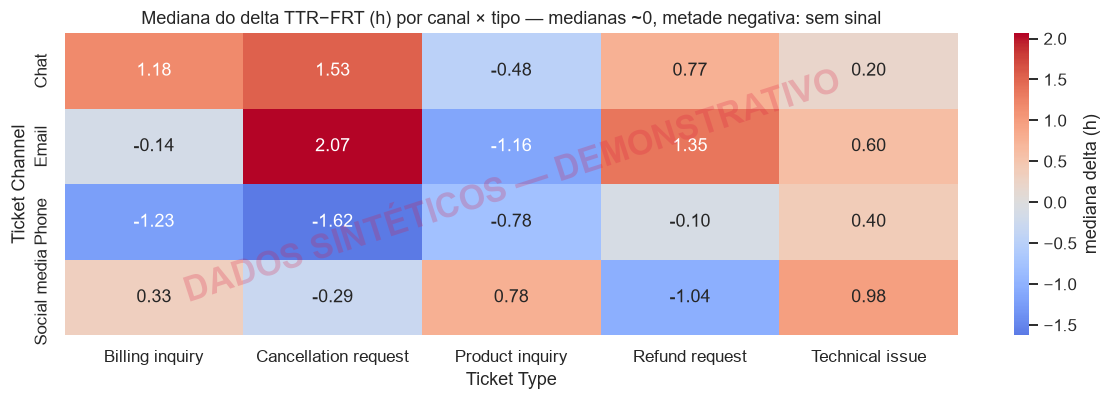

Marca d'água DENTRO do PNG (D-011): o rótulo sobrevive a screenshot.


In [8]:
piv_d = closed.pivot_table(values=delta_h.name, index="Ticket Channel", columns="Ticket Type",
                           aggfunc="median", observed=True) if False else None
demo = closed.assign(delta_h=delta_h)
piv_d = demo.pivot_table(values="delta_h", index="Ticket Channel", columns="Ticket Type",
                         aggfunc="median", observed=True)
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.heatmap(piv_d, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "mediana delta (h)"})
watermark(ax)
ax.set_title("Mediana do delta TTR−FRT (h) por canal × tipo — medianas ~0, metade negativa: sem sinal")
fig.tight_layout(); fig.savefig(ASSETS / "p3_demo_delta_heatmap.png", bbox_inches="tight"); plt.show()
print("Marca d'água DENTRO do PNG (D-011): o rótulo sobrevive a screenshot.")

---
# PERGUNTA 2 — O que impacta a satisfação? (Closed, n=2.769)

**Desenho pré-declarado (D-011):**
1. Análises principais usam apenas features `measured` — as colunas sintéticas ficam FORA de OLS/RF
   (coerência com o guardrail da FASE 2); a exigência do plano de testar FRT/TTR é cumprida na rodada
   demonstrativa (§2.6).
2. Família de testes com correção **Benjamini-Hochberg**; com ~15 testes sob H0, 1 p<0,05 espúrio seria
   esperado SEM correção — antecipamos isso antes de rodar.
3. Nulos são reportados com **limites de efeito** (IC 95%), nunca como "prova de ausência".

## 2.1 Correlações (Spearman + Kendall tau-b como robustez a empates)

             feature  spearman  IC95_lo  IC95_hi  kendall_tau_b      p   p_BH
       priority_rank   -0.0214  -0.0586   0.0158        -0.0176 0.2594 0.6965
        Customer Age   -0.0040  -0.0413   0.0332        -0.0030 0.8315 0.8315
   description_words    0.0041  -0.0331   0.0414         0.0031 0.8277 0.8315
    resolution_words    0.0206  -0.0167   0.0578         0.0163 0.2786 0.6965
tickets_per_customer   -0.0071  -0.0443   0.0302        -0.0063 0.7105 0.8315

Limite superior de efeito: com 95% de confiança, nenhuma correlação excede |rho| = 0.059.


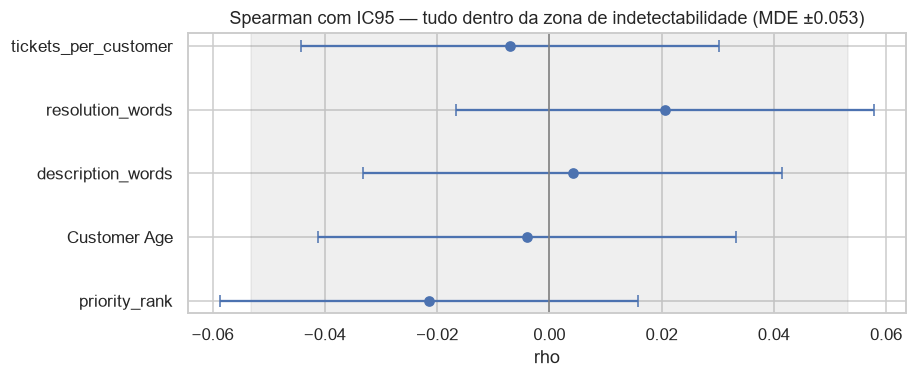

In [9]:
def spearman_ci(x, y):
    m = x.notna() & y.notna()
    r = stats.spearmanr(x[m], y[m]).statistic
    n = int(m.sum())
    z, hw = np.arctanh(r), 1.96 / np.sqrt(n - 3)
    return r, np.tanh(z - hw), np.tanh(z + hw), n

feats = {
    "priority_rank": closed["priority_rank"],
    "Customer Age": closed["Customer Age"],
    "description_words": closed["description_words"],
    "resolution_words": closed["resolution_words"].astype(float),
    "tickets_per_customer": closed["tickets_per_customer"],
}
rows = []
for name, s in feats.items():
    r, lo, hi, n = spearman_ci(closed[SAT], s)
    p = stats.spearmanr(closed[SAT], s, nan_policy="omit").pvalue
    tau = stats.kendalltau(closed[SAT], s, nan_policy="omit").statistic
    rows.append({"feature": name, "spearman": r, "IC95_lo": lo, "IC95_hi": hi,
                 "kendall_tau_b": tau, "p": p})
sp = pd.DataFrame(rows)
sp["p_BH"] = stats.false_discovery_control(sp["p"])
print(sp.round(4).to_string(index=False))
max_abs = sp[["IC95_lo", "IC95_hi"]].abs().max().max()
print(f"\nLimite superior de efeito: com 95% de confiança, nenhuma correlação excede |rho| = {max_abs:.3f}.")

fig, ax = plt.subplots(figsize=(8.5, 3.6))
y = np.arange(len(sp))
ax.errorbar(sp["spearman"], y, xerr=[sp["spearman"] - sp["IC95_lo"], sp["IC95_hi"] - sp["spearman"]],
            fmt="o", color=BLUE, capsize=4)
ax.axvline(0, color="gray", lw=1)
mde = np.tanh((stats.norm.ppf(0.975) + stats.norm.ppf(0.80)) / np.sqrt(len(closed) - 3))
ax.axvspan(-mde, mde, alpha=0.12, color="gray")
ax.set_yticks(y, sp["feature"])
ax.set_title(f"Spearman com IC95 — tudo dentro da zona de indetectabilidade (MDE ±{mde:.3f})")
ax.set_xlabel("rho")
fig.tight_layout(); fig.savefig(ASSETS / "p3_effects_ci.png", bbox_inches="tight"); plt.show()

## 2.2 ANOVA / Kruskal-Wallis por segmento (com tamanho de efeito e IC bootstrap)

In [10]:
def eta2(df, col):
    grand = df[SAT].mean()
    groups = df.groupby(col, observed=True)[SAT]
    ssb = sum(len(g) * (g.mean() - grand) ** 2 for _, g in groups)
    sst = ((df[SAT] - grand) ** 2).sum()
    return ssb / sst

rng = np.random.default_rng(42)
rows = []
for col in SEGS:
    groups = [g[SAT].values for _, g in closed.groupby(col, observed=True)]
    f = stats.f_oneway(*groups)
    kw = stats.kruskal(*groups)
    e2 = eta2(closed, col)
    boot = [eta2(closed.sample(frac=1, replace=True, random_state=int(s)), col)
            for s in rng.integers(0, 1_000_000, 500)]
    rows.append({"segmento": col, "F": f.statistic, "p_ANOVA": f.pvalue, "p_KW": kw.pvalue,
                 "eta2": e2, "eta2_IC95_hi": np.percentile(boot, 97.5)})
an = pd.DataFrame(rows)
an["p_BH"] = stats.false_discovery_control(an["p_ANOVA"])
print(an.round(4).to_string(index=False))

from statsmodels.stats.multicomp import pairwise_tukeyhsd
max_bound = 0.0
for col in SEGS:
    t = pairwise_tukeyhsd(closed[SAT], closed[col].astype(str))
    bound = max(abs(t.confint).max() for _ in [0])
    max_bound = max(max_bound, float(np.abs(t.confint).max()))
print(f"\nLimite superior (Tukey HSD 95%, todos os pares de todos os segmentos): nenhuma diferença")
print(f"entre grupos excede {max_bound:.2f} ponto na escala 1-5. Em termos executivos: mesmo o pior")
print("cenário compatível com os dados moveria a satisfação menos de ~0,25 ponto trocando de segmento.")

       segmento      F  p_ANOVA   p_KW   eta2  eta2_IC95_hi   p_BH
 Ticket Channel 1.2808   0.2792 0.2785 0.0014        0.0074 0.7008
    Ticket Type 0.5475   0.7008 0.6993 0.0008        0.0057 0.7008
Ticket Priority 0.5722   0.6333 0.6287 0.0006        0.0054 0.7008



Limite superior (Tukey HSD 95%, todos os pares de todos os segmentos): nenhuma diferença
entre grupos excede 0.33 ponto na escala 1-5. Em termos executivos: mesmo o pior
cenário compatível com os dados moveria a satisfação menos de ~0,25 ponto trocando de segmento.


## 2.3 Regressão OLS (erros-padrão robustos HC3) e robustez ordinal

In [11]:
import statsmodels.formula.api as smf

cl = closed.rename(columns={SAT: "rating", "Ticket Type": "type", "Ticket Channel": "channel",
                            "Ticket Priority": "priority", "Customer Age": "age"})
cl["type"] = cl["type"].astype(str); cl["channel"] = cl["channel"].astype(str)
cl["priority"] = cl["priority"].astype(str)
m = smf.ols("rating ~ C(type) + C(channel) + C(priority) + age", data=cl).fit(cov_type="HC3")
print(f"OLS (HC3): R2={m.rsquared:.5f} | R2 adj={m.rsquared_adj:.5f} | F p={m.f_pvalue:.3f} | n={int(m.nobs)}")
sig = m.pvalues.drop("Intercept")[lambda s: s < 0.05]
print("Coeficientes p<0,05 (sem correção):", dict(sig.round(3)) if len(sig) else "nenhum")

cl["is_dissat"] = cl["is_dissatisfied"].astype(bool).astype(int)
logit = smf.logit("is_dissat ~ C(type) + C(channel) + C(priority) + age", data=cl).fit(disp=0)
print(f"\nRobustez ordinal-binária (logística, alvo is_dissatisfied):")
print(f"  pseudo-R2={logit.prsquared:.5f} | LR p={logit.llr_pvalue:.3f}")
print("  (rating 1-5 é ordinal; OLS é exigência do plano — a logística confirma o mesmo nulo")
print("   sem assumir escala intervalar.)")

OLS (HC3): R2=0.00284 | R2 adj=-0.00114 | F p=0.727 | n=2769
Coeficientes p<0,05 (sem correção): nenhum

Robustez ordinal-binária (logística, alvo is_dissatisfied):
  pseudo-R2=0.00288 | LR p=0.468
  (rating 1-5 é ordinal; OLS é exigência do plano — a logística confirma o mesmo nulo
   sem assumir escala intervalar.)


## 2.4 Random Forest Regressor — com baseline de alvo embaralhado

Um gráfico de *feature importance* de um modelo **sem poder preditivo é ranking de ruído**. Por isso o
baseline: se as importâncias reais forem indistinguíveis das obtidas com o alvo embaralhado, nenhuma
feature "importa".

R2 CV (5-fold): -0.0217 ± 0.0085 -> NEGATIVO: pior que prever a média.
(Reportado como está — truncar em zero esconderia a ausência de sinal.)


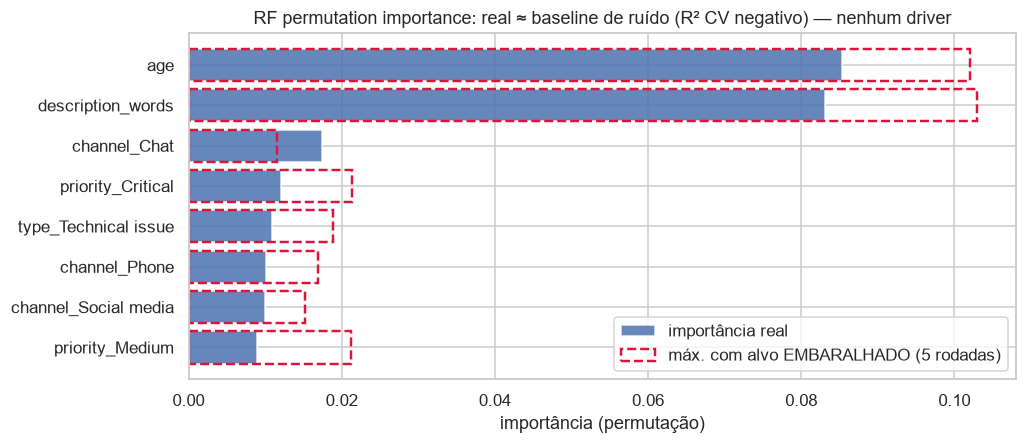

Leitura: as barras reais não superam consistentemente o contorno tracejado (ruído puro).


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance

X = pd.get_dummies(cl[["type", "channel", "priority"]])
X["age"] = cl["age"].values
X["description_words"] = cl["description_words"].values
y = cl["rating"].values

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
scores = cross_val_score(rf, X, y, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
print(f"R2 CV (5-fold): {scores.mean():.4f} ± {scores.std():.4f} -> NEGATIVO: pior que prever a média.")
print("(Reportado como está — truncar em zero esconderia a ausência de sinal.)")

rf.fit(X, y)
pi_real = permutation_importance(rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
real = pd.Series(pi_real.importances_mean, index=X.columns)

rng = np.random.default_rng(7)
null_imps = []
for i in range(5):
    y_perm = rng.permutation(y)
    rf_n = RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=i, n_jobs=-1)
    rf_n.fit(X, y_perm)
    pi_n = permutation_importance(rf_n, X, y_perm, n_repeats=5, random_state=i, n_jobs=-1)
    null_imps.append(pd.Series(pi_n.importances_mean, index=X.columns))
null_df = pd.DataFrame(null_imps)

top = real.sort_values(ascending=False).head(8)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ypos = np.arange(len(top))
ax.barh(ypos, top.values, color=BLUE, alpha=0.85, label="importância real")
nmax = null_df[top.index].max()
ax.barh(ypos, nmax.values, color="none", edgecolor=RED, lw=1.6, ls="--",
        label="máx. com alvo EMBARALHADO (5 rodadas)")
ax.set_yticks(ypos, top.index); ax.invert_yaxis()
ax.set_title("RF permutation importance: real ≈ baseline de ruído (R² CV negativo) — nenhum driver")
ax.legend(); ax.set_xlabel("importância (permutação)")
fig.tight_layout(); fig.savefig(ASSETS / "p3_rf_importance_null.png", bbox_inches="tight"); plt.show()
print("Leitura: as barras reais não superam consistentemente o contorno tracejado (ruído puro).")

## 2.5 Poder estatístico: o que estes nulos DESCARTAM (MDE calculado em código)

In [13]:
from statsmodels.stats.power import FTestAnovaPower

n = len(closed)
z_a, z_b = stats.norm.ppf(0.975), stats.norm.ppf(0.80)
mde_rho = np.tanh((z_a + z_b) / np.sqrt(n - 3))
print(f"n = {n:,} (Closed)")
print(f"Spearman: MDE |rho| = {mde_rho:.4f} (alpha=0,05, poder=0,80, Fisher-z)")
for k, name in [(5, "Ticket Type"), (4, "Ticket Channel / Priority")]:
    f_mde = FTestAnovaPower().solve_power(effect_size=None, nobs=n, alpha=0.05, power=0.80, k_groups=k)
    print(f"ANOVA {name} (k={k}): MDE f = {f_mde:.4f} (eta2 ~ {f_mde**2 / (1 + f_mde**2):.4f})")
print()
print("Formulação correta: NÃO detectamos sinal, e o desenho limita qualquer efeito real não detectado")
print(f"a |rho| < ~{mde_rho:.3f} e eta2 < ~0,004. Combinado com os ICs (§2.1-2.2): efeitos de negócio")
print("relevantes (>0,25 ponto de satisfação) são INCOMPATÍVEIS com estes dados.")

n = 2,769 (Closed)
Spearman: MDE |rho| = 0.0532 (alpha=0,05, poder=0,80, Fisher-z)
ANOVA Ticket Type (k=5): MDE f = 0.0657 (eta2 ~ 0.0043)
ANOVA Ticket Channel / Priority (k=4): MDE f = 0.0628 (eta2 ~ 0.0039)

Formulação correta: NÃO detectamos sinal, e o desenho limita qualquer efeito real não detectado
a |rho| < ~0.053 e eta2 < ~0,004. Combinado com os ICs (§2.1-2.2): efeitos de negócio
relevantes (>0,25 ponto de satisfação) são INCOMPATÍVEIS com estes dados.


## 2.6 Rodada demonstrativa — FRT/TTR sintéticos (exigência literal do plano)

In [14]:
frt_epoch = closed["synthetic_first_response_ts"].astype("int64")
ttr_epoch = closed["synthetic_resolution_ts"].astype("int64")
delta_min = closed["synthetic_delta_resolution_minutes"]
res = []
for name, s in {"First Response Time (epoch)": frt_epoch,
                "Time to Resolution (epoch)": ttr_epoch,
                "delta TTR−FRT (min)": delta_min}.items():
    r = stats.spearmanr(closed[SAT], s)
    res.append({"medida": name, "rho": r.statistic, "p": r.pvalue})
demo_sp = pd.DataFrame(res)
demo_sp["p_BH"] = stats.false_discovery_control(demo_sp["p"])
print("[SINTÉTICO — DEMONSTRATIVO] Spearman com rating (n=2.769), família com correção BH:")
print(demo_sp.round(4).to_string(index=False))
print()
print("Nota metodológica: o FRT aparece com p=0,046 SEM correção — exatamente o falso-positivo")
print("esperado que a política pré-declarada de múltiplas comparações (§P2) antecipou: |rho|=0,038")
print("está ABAIXO do MDE (0,053), a correção BH da família leva p para ~0,14, e a coluna é um")
print("timestamp sorteado (D-005). Um pipeline sem correção reportaria isso como 'achado'.")

[SINTÉTICO — DEMONSTRATIVO] Spearman com rating (n=2.769), família com correção BH:
                     medida     rho      p   p_BH
First Response Time (epoch) -0.0379 0.0464 0.1391
 Time to Resolution (epoch) -0.0105 0.5814 0.5814
        delta TTR−FRT (min)  0.0217 0.2539 0.3808

Nota metodológica: o FRT aparece com p=0,046 SEM correção — exatamente o falso-positivo
esperado que a política pré-declarada de múltiplas comparações (§P2) antecipou: |rho|=0,038
está ABAIXO do MDE (0,053), a correção BH da família leva p para ~0,14, e a coluna é um
timestamp sorteado (D-005). Um pipeline sem correção reportaria isso como 'achado'.


## 2.7 Conclusões acionáveis da P2

1. **Decisão de alocação:** não priorize automação por "driver de satisfação" — não há segmento vilão.
   Priorize por **volume × custo** (ponte para a P3): deflexão horizontal + velocidade de primeira resposta.
2. **Instrumentação (artefato formal):** o nulo mais caro deste diagnóstico é o que a operação NÃO mede.

| Campo/evento a instrumentar | Métrica destravada | Decisão habilitada |
|---|---|---|
| `created_at` (abertura) | First Response Time e TTR **reais** | SLA por prioridade; staffing por hora |
| `first_response_at` | tempo de 1ª resposta real | meta de resposta; alavanca nos 33% Open |
| `resolved_at` + `closed_at` | tempo de resolução real; aging de fila | gargalos reais por segmento |
| `reopen_flag` / contato repetido | FCR (first contact resolution) | qualidade da deflexão da IA |
| CSAT no fechamento (todos) | satisfação sem viés de seleção | drivers reais (re-rodar este pipeline) |

3. **Pipeline reexecutável:** este notebook roda de ponta a ponta sobre os dados; com timestamps reais
   instrumentados, as mesmas células (Spearman/ANOVA/OLS/RF com baseline) produzem o diagnóstico
   verdadeiro trimestralmente — o método é o entregável.

---
# PERGUNTA 3 — Quanto estamos desperdiçando? (modelo de ROI)

**Ponte P2→P3 (obrigatória):** o caso econômico abaixo é 100% de **custo** (horas de agente evitadas) — ele
NÃO assume melhoria de satisfação, coerente com o nulo da P2. Reduzir os 33% sem resposta e os 39,8% de
detratores é **upside estratégico não contabilizado** (hipótese de piloto). O ROI quantificado é, portanto,
o **piso** do caso de negócio.

Modelo (fonte única): [`src/roi_model.py`](../src/roi_model.py) — fórmulas no docstring, premissas com faixas,
13 testes de sanidade matemática. Deflexões por tipo são **premissas provisórias a ratificar na FASE 4**
(que importa as mesmas constantes) e validar em piloto.

In [15]:
print("PREMISSAS (low/base/high) — performance e custo recorrente viram sliders; implantação é fixa em R$ 0:\n")
print("Deflexão por tipo (líquida de escalação):")
for t, v in DEFLECTION_BY_TYPE.items():
    print(f"  {t:<22} {v['low']:.0%} / {v['base']:.0%} / {v['high']:.0%}")
print(f"Assistência (redução de AHT no restante): {ASSIST_AHT_REDUCTION}")
print(f"Ramp-up ano 1: {RAMP_UP_YEAR1}")
print(f"Implantação (R$): {SOLUTION_IMPL_COST_BRL}")
print(f"Run por ticket (R$) — tokens+plataforma+sustentação, sobre TODOS os tickets: {SOLUTION_RUN_COST_PER_TICKET_BRL}")
print(f"Horas produtivas/FTE/ano: {FTE_PRODUCTIVE_HOURS_YEAR}")
print(f"Volume anual: {TICKETS_PER_YEAR_RANGE}")

PREMISSAS (low/base/high) — performance e custo recorrente viram sliders; implantação é fixa em R$ 0:

Deflexão por tipo (líquida de escalação):
  Product inquiry        50% / 65% / 80%
  Billing inquiry        30% / 45% / 60%
  Refund request         20% / 35% / 50%
  Cancellation request   15% / 25% / 40%
  Technical issue        10% / 20% / 30%
Assistência (redução de AHT no restante): {'low': 0.1, 'base': 0.2, 'high': 0.3}
Ramp-up ano 1: {'low': 0.5, 'base': 0.65, 'high': 0.8}
Implantação (R$): {'low': 0.0, 'base': 0.0, 'high': 0.0}
Run por ticket (R$) — tokens+plataforma+sustentação, sobre TODOS os tickets: {'low': 0.5, 'base': 1.0, 'high': 2.0}
Horas produtivas/FTE/ano: {'low': 1560.0, 'base': 1680.0, 'high': 1800.0}
Volume anual: {'low': 24000.0, 'base': 30000.0, 'high': 36000.0}


In [16]:
base = roi_scenario(d1, "base")
asis = roi_scenario(d1, "base", tickets_year=float(len(d1)))
print("=== O TAMANHO DO DESPERDÍCIO (cenário base de premissas) ===\n")
print(f"Carga anual (30k tickets): {base.hours_year:,.0f} horas = {base.fte:.1f} FTE = R$ {base.cost_year_brl:,.0f}/ano")
print(f"  (na amostra as-is, sem anualizar: {asis.hours_year:,.0f} h = R$ {asis.cost_year_brl:,.0f})")
print(f"\nEconomia potencial em regime (deflexão + assistência): {base.hours_saved:,.0f} h/ano")
print(f"  = {base.fte_saved:.1f} FTE de CAPACIDADE LIBERADA = R$ {base.gross_savings_brl:,.0f}/ano brutos")
print(f"  ({base.deflected_tickets:,.0f} tickets defletidos + {base.assist_hours:,.0f} h de assistência)")
print("\nATENÇÃO — 'capacidade liberada' não é corte automático de custo: a captura exige decisão de")
print("realocação. Recomendação: apontar a capacidade para os 33,3% de tickets sem primeira resposta")
print("(amarração P1<->P3: mesma equipe, backlog zerado, sem contratação).")

=== O TAMANHO DO DESPERDÍCIO (cenário base de premissas) ===

Carga anual (30k tickets): 9,207 horas = 5.5 FTE = R$ 368,263/ano
  (na amostra as-is, sem anualizar: 2,599 h = R$ 103,961)

Economia potencial em regime (deflexão + assistência): 4,404 h/ano
  = 2.6 FTE de CAPACIDADE LIBERADA = R$ 176,170/ano brutos
  (11,294 tickets defletidos + 1,201 h de assistência)

ATENÇÃO — 'capacidade liberada' não é corte automático de custo: a captura exige decisão de
realocação. Recomendação: apontar a capacidade para os 33,3% de tickets sem primeira resposta
(amarração P1<->P3: mesma equipe, backlog zerado, sem contratação).


=== CENÁRIOS DE NEGÓCIO (economia e custo pareados em direções opostas) ===
scenario                 conservador      base  otimista
h economizadas (regime)      1,805.3   4,404.2   8,621.9
FTE liberados                    1.1       2.6       5.1
econ. bruta regime R$       54,158.7 176,169.8 474,205.5
econ. ano1 (ramp) R$        27,079.4 114,510.4 379,364.4
custo sol. ano1 R$          60,000.0  30,000.0  15,000.0
líquida ano1 R$            -32,920.6  84,510.4 364,364.4
ROI ano1                        -0.5       2.8      24.3
líquida regime R$           -5,841.3 146,169.8 459,205.5
ROI regime                      -0.1       4.9      30.6
payback (meses)                  inf       0.0       0.0


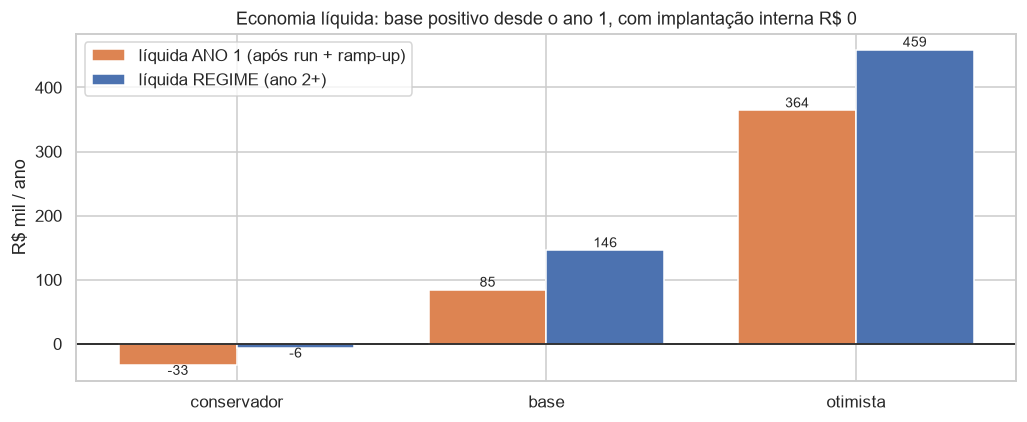

In [17]:
scen = pd.DataFrame([roi_business_scenario(d1, s).as_dict()
                     for s in ["conservador", "base", "otimista"]]).set_index("scenario")
show = scen[["hours_saved", "fte_saved", "gross_savings_brl", "savings_year1_brl",
             "solution_cost_year1_brl", "net_savings_year1_brl", "roi_year1",
             "net_savings_steady_brl", "roi_steady", "payback_months"]].copy()
show.columns = ["h economizadas (regime)", "FTE liberados", "econ. bruta regime R$",
                "econ. ano1 (ramp) R$", "custo sol. ano1 R$", "líquida ano1 R$", "ROI ano1",
                "líquida regime R$", "ROI regime", "payback (meses)"]
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
print("=== CENÁRIOS DE NEGÓCIO (economia e custo pareados em direções opostas) ===")
print(show.T.to_string())
pd.reset_option("display.float_format")

fig, ax = plt.subplots(figsize=(9.5, 4))
x = np.arange(3); wd = 0.38
names = ["conservador", "base", "otimista"]
y1 = [scen.loc[s, "net_savings_year1_brl"] / 1000 for s in names]
ys = [scen.loc[s, "net_savings_steady_brl"] / 1000 for s in names]
ax.bar(x - wd / 2, y1, wd, label="líquida ANO 1 (após run + ramp-up)", color=ORANGE)
ax.bar(x + wd / 2, ys, wd, label="líquida REGIME (ano 2+)", color=BLUE)
ax.axhline(0, color="black", lw=1)
for xi, (a, b) in zip(x, zip(y1, ys)):
    ax.text(xi - wd / 2, a, f"{a:,.0f}", ha="center", va="bottom" if a > 0 else "top", fontsize=9)
    ax.text(xi + wd / 2, b, f"{b:,.0f}", ha="center", va="bottom" if b > 0 else "top", fontsize=9)
ax.set_xticks(x, names); ax.set_ylabel("R$ mil / ano")
ax.set_title("Economia líquida: base positivo desde o ano 1, com implantação interna R$ 0")
ax.legend()
fig.tight_layout(); fig.savefig(ASSETS / "p3_scenarios.png", bbox_inches="tight"); plt.show()

In [18]:
be = break_even_deflection(d1)
run_be = base.run_cost_year_brl / (base.hours_year * AGENT_COST_BRL_PER_HOUR["base"])
print("=== BREAK-EVEN (raciocínio de diretor) ===\n")
print(f"Para pagar o custo recorrente do ano 1 só com deflexão (sem assistência):")
print(f"  deflexão uniforme necessária = {be:.1%}  -> paga o custo recorrente já no ramp-up.")
print(f"\nPara pagar o RUN em regime (ano 2+):")
print(f"  deflexão uniforme necessária = {run_be:.1%}  -> trivial de atingir; o regime se paga com folga.")
print(f"\nLeitura: o risco está na performance durante o ramp-up e no custo recorrente.")

=== BREAK-EVEN (raciocínio de diretor) ===

Para pagar o custo recorrente do ano 1 só com deflexão (sem assistência):
  deflexão uniforme necessária = 12.5%  -> paga o custo recorrente já no ramp-up.

Para pagar o RUN em regime (ano 2+):
  deflexão uniforme necessária = 8.1%  -> trivial de atingir; o regime se paga com folga.

Leitura: o risco está na performance durante o ramp-up e no custo recorrente.


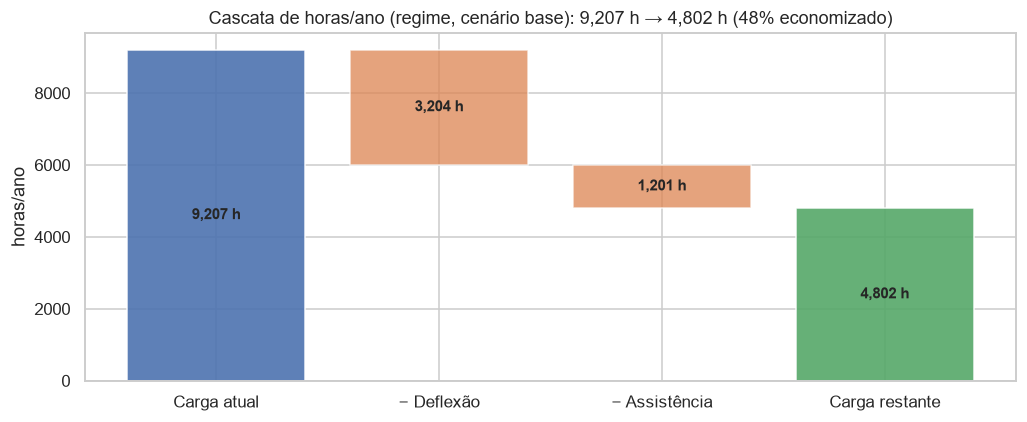

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 4))
stages = ["Carga atual", "− Deflexão", "− Assistência", "Carga restante"]
defl, assist = base.deflected_hours, base.assist_hours
rest = base.hours_year - base.hours_saved
starts = [0, rest + assist, rest, 0]
heights = [base.hours_year, defl, assist, rest]
colors = [BLUE, ORANGE, ORANGE, sns.color_palette("deep")[2]]
for i, (s, h, c) in enumerate(zip(starts, heights, colors)):
    ax.bar(i, h, bottom=s, color=c, alpha=0.9 if i in (0, 3) else 0.75)
    ax.text(i, s + h / 2, f"{h:,.0f} h", ha="center", va="center", fontsize=10, fontweight="bold")
ax.set_xticks(range(4), stages)
ax.set_title(f"Cascata de horas/ano (regime, cenário base): {base.hours_year:,.0f} h → {rest:,.0f} h "
             f"({base.hours_saved / base.hours_year:.0%} economizado)")
ax.set_ylabel("horas/ano")
fig.tight_layout(); fig.savefig(ASSETS / "p3_hours_waterfall.png", bbox_inches="tight"); plt.show()

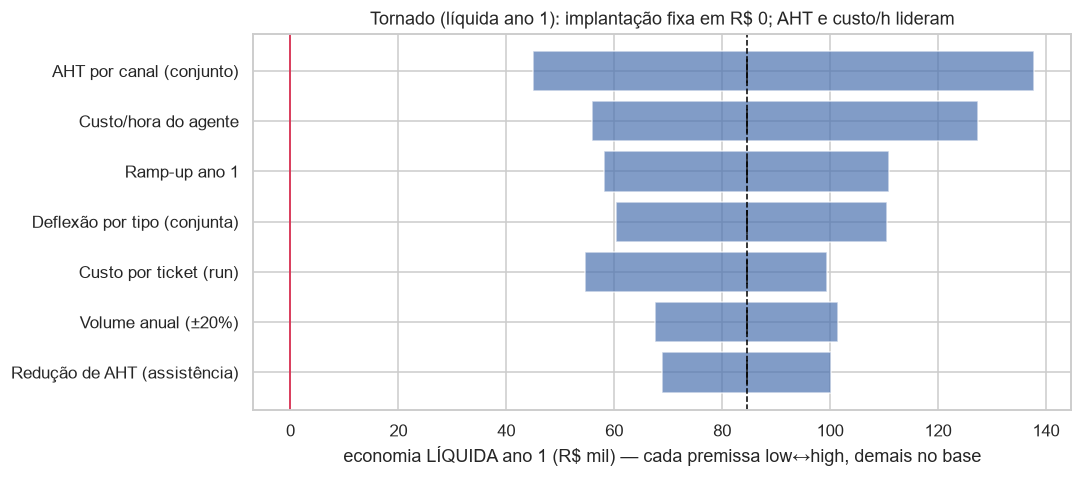

                    premissa  net_low  net_high  net_base  amplitude
    AHT por canal (conjunto)  45024.0  137817.0   84510.0    92793.0
        Custo/hora do agente  55883.0  127452.0   84510.0    71569.0
               Ramp-up ano 1  58085.0  110936.0   84510.0    52851.0
Deflexão por tipo (conjunta)  60278.0  110619.0   84510.0    50341.0
      Custo por ticket (run)  99510.0   54510.0   84510.0    45000.0
         Volume anual (±20%)  67608.0  101412.0   84510.0    33804.0
Redução de AHT (assistência)  68903.0  100118.0   84510.0    31215.0

Leituras: (1) implantação é premissa fixa em R$ 0 e não entra na sensibilidade;
(2) AHT e custo/h lideram -> medir tempos REAIS nas primeiras semanas recalibra o modelo;
(3) ramp-up, deflexão e custo recorrente determinam se o resultado positivo se sustenta.


In [20]:
t = sensitivity_tornado(d1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ypos = np.arange(len(t))[::-1]
for i, row in t.iterrows():
    lo, hi, b = row["net_low"] / 1000, row["net_high"] / 1000, row["net_base"] / 1000
    ax.barh(ypos[i], hi - lo, left=lo, color=BLUE, alpha=0.7)
    ax.plot([b], [ypos[i]], "k|", ms=16)
ax.axvline(t["net_base"].iloc[0] / 1000, color="black", lw=1, ls="--")
ax.axvline(0, color=RED, lw=1)
ax.set_yticks(ypos, t["premissa"])
ax.set_xlabel("economia LÍQUIDA ano 1 (R$ mil) — cada premissa low↔high, demais no base")
ax.set_title("Tornado (líquida ano 1): implantação fixa em R$ 0; AHT e custo/h lideram")
fig.tight_layout(); fig.savefig(ASSETS / "p3_tornado.png", bbox_inches="tight"); plt.show()
print(t.round(0).to_string(index=False))
print()
print("Leituras: (1) implantação é premissa fixa em R$ 0 e não entra na sensibilidade;")
print("(2) AHT e custo/h lideram -> medir tempos REAIS nas primeiras semanas recalibra o modelo;")
print("(3) ramp-up, deflexão e custo recorrente determinam se o resultado positivo se sustenta.")

## Custo de não fazer nada (ilustrativo, fora do modelo)

O modelo acima ignora o lado receita por falta de dados. Fórmula paramétrica para discussão:
`custo_churn ≈ detratores_ano × taxa_de_cancelamento × LTV`. Com 39,8% de detratores sobre ~9.800 tickets
fechados/ano (30k × 32,7%), **cada 1% de cancelamento entre detratores × R$ 1.000 de LTV ≈ R$ 39 mil/ano** —
na ordem de grandeza de toda a economia de custo do cenário base. Não entra no ROI (seria falsa precisão);
entra na conversa como razão para o piloto medir churn de detratores.

## Síntese da P3 e limitações do modelo

| # | Limitação | Efeito |
|---|---|---|
| 1 | AHT e custo/h são premissas (D-005: tempos sintéticos) | valores absolutos dependem da calibração — faixas e tornado dimensionam a incerteza |
| 2 | Volumes ~uniformes (dados sintéticos) | ranking de pools é premissa-dependente (disclosure §1.5) |
| 3 | Deflexões são hipóteses de mercado | validar em piloto; FASE 4 ratifica a matriz importando estas constantes |
| 4 | Economia = capacidade liberada | captura exige decisão de realocação (recomendada: backlog Open) |
| 5 | Ramp-up linear na economia do ano 1 | resultado real depende da curva de adoção |
| 6 | Lado receita fora do modelo | upside de CX não contabilizado — ROI é piso |

**Resposta ao diretor:** a operação custa ~**R$ 368 mil/ano** (9.207 h, 5,5 FTE) sob premissas base.
A automação libera ~**2,6 FTE (R$ 176 mil/ano brutos em regime)**. Com implantação interna e custo incremental
**R$ 0**, o ano 1 entrega **R$ 84,5 mil líquidos (ROI 282%, payback imediato)**; em regime, devolve
**R$ 146 mil/ano líquidos (ROI 487%)**. No conservador o projeto não se paga por baixa performance e custo
recorrente — por isso a recomendação é **piloto com gates** para validar AHT, deflexão, ramp-up e custo/ticket.